# Stationary Heston Simulation

This notebook aims to reproduce and analyse some of the main ideas of the article. The first objective is to compare the three initial-variance choices:

- `GAMMA`: draw the initial variance from the invariant Gamma law of the CIR process,
- `MEAN`: start deterministically from the long-run level `theta`,
- `LAST_VALUE`: start from a fixed observed variance level, here `0.0045` as in the article.

**Methodological note.** In this first part, the three strategies are compared under the **same Heston parameters**. This is deliberate: it isolates the effect of the initialisation rule itself. If we used the two different calibrated parameter sets of Table 2 at the same time, we would mix two effects together: a change of initialisation and a change of model parameters.

The analysis is split in three blocks:

1. the standalone CIR variance process,
2. the full Heston asset/variance dynamics under the same three initialisations,
3. the pricing of European, Bermudan, and Barrier options.

In [19]:
#Useful imports

from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../")

plt.style.use("seaborn-v0_8-whitegrid")

from stationary_heston_model import (
    BarrierDirection,
    BarrierOption,
    BermudanOption,
    CIRStationarySimulator,
    EuropeanOption,
    HestonPathSimulator,
    InitialVarianceStrategy,
    OptionType,
)


## Model setup  

The volatility process is the CIR diffusion

$$
dv_t = \, \kappa(\theta - v_t)\,dt + \xi \sqrt{v_t}\,dW_t,
$$

with invariant law

$$
\nu = \Gamma(\alpha, \beta), \qquad \alpha = \frac{2\kappa\theta}{\xi^2}, \qquad \beta = \frac{2\kappa}{\xi^2},
$$

using the paper's shape-rate parameterisation. In the repository implementation, the stationary sampler therefore uses the equivalent shape-scale form with $\text{scale} = \frac{1}{\beta}$.

We use the penalised calibration reported in Table 2 of the paper. Reproducing the values directly in Markdown, modulo $S_0$, gives:

| Model | $r$ | $q$ | $\rho$ | $v_0$ | $\theta$ | $\kappa$ | $\xi$ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Standard Heston | -0.0032 | 0.00225 | -0.83 | 0.0045 | 0.17023 | 2.19 | 1.04 |
| Stationary Heston | -0.0032 | 0.00225 | -0.99 | n/a | 0.02691 | 19.28 | 1.15 |

For the stationary model, $v_0$ is not a deterministic calibrated parameter: the paper uses $v_0^\nu \sim \Gamma(\alpha, \beta)$. In the simulations below, we keep $S_0 = 100$ for convenience and use last variance $v_0 = 0.0045$ when comparing against the deterministic `LAST_VALUE` strategy.

A useful benchmark is the exact conditional mean of the CIR process:

$$
\mathbb{E}[v_t \mid v_0] = \theta + (v_0 - \theta)e^{-\kappa t}.
$$

This formula is enough to anticipate most of the comparisons below: `MEAN` starts directly at the long-run level, `LAST_VALUE` mean-reverts exponentially towards it, and `GAMMA` is stationary from time zero because its full distribution is already invariant.


In [20]:
s0 = 100
r = -0.0032
q = 0.00225
kappa = 19.28
theta = 0.02691
xi = 1.15
rho = -0.99
last_variance = 0.0045

short_maturity = 7 / 252
half_year = 0.5
n_paths = 30000

strategy_order = [
    InitialVarianceStrategy.GAMMA,
    InitialVarianceStrategy.MEAN,
    InitialVarianceStrategy.LAST_VALUE,
]
strategy_labels = {
    InitialVarianceStrategy.GAMMA: "GAMMA",
    InitialVarianceStrategy.MEAN: "MEAN",
    InitialVarianceStrategy.LAST_VALUE: "LAST_VALUE",
}
strategy_colors = {
    InitialVarianceStrategy.GAMMA: "#1f77b4",
    InitialVarianceStrategy.MEAN: "#2ca02c",
    InitialVarianceStrategy.LAST_VALUE: "#d62728",
}

alpha = 2.0 * kappa * theta / xi**2
beta = 2.0 * kappa / xi**2
scale = 1.0 / beta 
feller_gap = 2.0 * kappa * theta - xi**2

parameter_table = {
    "s0" : s0,
    "r" : r,
    "q" : q,
    "theta" : theta,
    "kappa" : kappa,
    "xi" : xi,
    "rho": rho,
    "last_variance" : last_variance,
    "stationary alpha" : alpha,
    "stationary beta" : beta,
    "stationary scale" : scale,
    "feller_gap" : feller_gap,
}

parameter_table


{'s0': 100,
 'r': -0.0032,
 'q': 0.00225,
 'theta': 0.02691,
 'kappa': 19.28,
 'xi': 1.15,
 'rho': -0.99,
 'last_variance': 0.0045,
 'stationary alpha': 0.7846121739130436,
 'stationary beta': 29.156899810964088,
 'stationary scale': 0.03429719917012448,
 'feller_gap': -0.28485039999999984}

The last row is negative, so the calibrated parameters do not satisfy the Feller condition. That is consistent with the discussion in the paper: even after penalisation, the calibration does not force the constraint. The repository therefore uses the boosted Milstein step for the variance and floors the numerical state at `1e-6` for robustness.

The helper functions below keep the notebook compact and make the comparisons reproducible.


In [ ]:
def cir_moment_paths(bundle: dict[InitialVarianceStrategy, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for strategy in strategy_order:
        times = bundle[strategy]["times"]
        variance = bundle[strategy]["variance"]
        for time_index, time in enumerate(times):
            sample = variance[:, time_index]
            moments = sample_moments(sample)
            rows.append({
                "strategy": strategy_labels[strategy],
                "time": float(time),
                **moments,
            })
    return pd.DataFrame(rows)


def time_steps_for(maturity: float) -> int:
    return max(20, int(np.ceil(252 * maturity)))


def exact_cir_mean(times: np.ndarray, v0: float) -> np.ndarray:
    return theta + (v0 - theta) * np.exp(-kappa * times)


def simulate_cir_bundle(parameters: dict[str, float], maturity: float, n_steps: int, n_paths: int, seed: int = None) -> dict[InitialVarianceStrategy, dict[str, np.ndarray]]:
    rng = None
    if seed:
        rng = np.random.default_rng(seed)
    results = {}
    for strategy in strategy_order:
        simulator = CIRStationarySimulator(theta=parameters["theta"], kappa=parameters["kappa"], xi=parameters["xi"], rng=rng)
        last_variance = None
        if strategy == InitialVarianceStrategy.LAST_VALUE:
            last_variance = parameters["last_variance"]
        times, variance = simulator.simulate(maturity=maturity, n_steps=n_steps, n_paths=n_paths, strategy=strategy, last_variance=last_variance)
        results[strategy] = {"times": times, "variance": variance}
    return results


def summarise_cir_bundle(bundle: dict[InitialVarianceStrategy, dict[str, np.ndarray]], time_index: int) -> pd.DataFrame:
    rows = []
    for strategy in strategy_order:
        sample = bundle[strategy]["variance"][:, time_index]
        rows.append(
            {
                "strategy": strategy_labels[strategy],
                "mean": float(np.mean(sample)),
                "std": float(np.std(sample, ddof=1)),
                "variance": float(np.var(sample, ddof=1)),
                "q05": np.quantile(sample, 0.05),
                "median": np.quantile(sample, 0.50),
                "q95": np.quantile(sample, 0.95),
                "skewness": float(scipy.stats.skew(sample, bias=False)),
                "kurtosis": float(scipy.stats.kurtosis(sample, fisher=False, bias=False)),
            }
        )
    return pd.DataFrame(rows).set_index("strategy")

def simulate_heston_bundle(maturity: float, n_steps: int, n_paths: int, seed: int) -> dict[InitialVarianceStrategy, dict[str, np.ndarray]]:
    results = {}
    for offset, strategy in enumerate(strategy_order):
        rng = np.random.default_rng(seed + offset)
        simulator = HestonPathSimulator(
            s0=s0,
            r=r,
            q=q,
            kappa=kappa,
            theta=theta,
            xi=xi,
            rho=rho,
            rng=rng,
        )
        kwargs = {"last_variance": last_variance} if strategy == InitialVarianceStrategy.LAST_VALUE else {}
        spot, variance = simulator.simulate(
            maturity=maturity,
            n_steps=n_steps,
            n_paths=n_paths,
            strategy=strategy,
            **kwargs,
        )
        results[strategy] = {"spot": spot, "variance": variance}
    return results


def summarise_heston_bundle(bundle: dict[InitialVarianceStrategy, dict[str, np.ndarray]], maturity: float) -> pd.DataFrame:
    rows = []
    target_mean = s0 * np.exp((r - q) * maturity)
    for strategy in strategy_order:
        spot = bundle[strategy]["spot"][:, -1]
        variance = bundle[strategy]["variance"][:, -1]
        log_returns = np.log(spot / s0)
        rows.append(
            {
                "strategy": strategy_labels[strategy],
                "E[S_T]": spot.mean(),
                "risk-neutral target": target_mean,
                "Std(S_T)": spot.std(ddof=1),
                "Q05(S_T)": np.quantile(spot, 0.05),
                "Q95(S_T)": np.quantile(spot, 0.95),
                "P(S_T < 95)": np.mean(spot < 95.0),
                "P(S_T > 105)": np.mean(spot > 105.0),
                "Std(log-return)": log_returns.std(ddof=1),
                "Skew(log-return)": sample_skewness(log_returns),
                "Corr(log-return, v_T)": np.corrcoef(log_returns, variance)[0, 1],
                "E[v_T]": variance.mean(),
            }
        )
    return pd.DataFrame(rows).set_index("strategy")


## 1. CIR simulation under the three initialisations

The CIR block is the cleanest place to understand what changes when we modify the initial variance law.
We compare:

- the distribution at time zero,
- the distribution after **7 trading days**, where the initial condition should still matter,
- the distribution after **6 months**, where the process should have mostly forgotten how it started.


In [45]:
cir_short = simulate_cir_bundle(parameters=parameter_table, maturity=short_maturity, n_steps=time_steps_for(short_maturity), n_paths=n_paths)
cir_half = simulate_cir_bundle(parameters=parameter_table, maturity=half_year, n_steps=time_steps_for(half_year), n_paths=n_paths)

print("Initial v0")
display(summarise_cir_bundle(cir_short, time_index=0))

print("terminal v_7d")
display(summarise_cir_bundle(cir_short, time_index=-1))

print("terminal v_6m")
display(summarise_cir_bundle(cir_half, time_index=-1))



/home/enzo/code/el_karoui/StationaryHestonModel/notebooks/../stationary_heston_model/diffusions/cir.py:43: UserWarning: The Feller condition is not satisfied.
  warn("The Feller condition is not satisfied.")


Initial v0


/var/tmp/ipykernel_4994/4136445091.py:62: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": float(scipy.stats.skew(sample, bias=False)),
/var/tmp/ipykernel_4994/4136445091.py:63: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurtosis": float(scipy.stats.kurtosis(sample, fisher=False, bias=False)),


,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,,,,,,,,
GAMMA,0.026964,3.046319e-02,9.280061e-04,0.000703,0.016738,0.087927,2.248567,10.326323
MEAN,0.026910,3.469505e-18,1.203746e-35,0.026910,0.026910,0.026910,NaN,NaN
LAST_VALUE,0.004500,8.673762e-19,7.523415e-37,0.004500,0.004500,0.004500,NaN,NaN


terminal v_7d


,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,,,,,,,,
GAMMA,0.026873,0.030290,0.000917,0.000797,0.016526,0.087626,2.232374,10.147287
MEAN,0.026893,0.024615,0.000606,0.001210,0.020125,0.076033,1.556573,6.182202
LAST_VALUE,0.013462,0.014756,0.000218,0.000461,0.008499,0.043329,2.088739,9.002352


terminal v_6m


,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,,,,,,,,
GAMMA,0.026072,0.029309,0.000859,0.001034,0.016172,0.085038,2.233882,10.068867
MEAN,0.026224,0.029654,0.000879,0.001014,0.016275,0.084782,2.338454,11.363673
LAST_VALUE,0.025935,0.029079,0.000846,0.001049,0.016085,0.083974,2.255899,10.467468


For the `GAMMA` strategy, the theoretical benchmark is the invariant Gamma law of the CIR process. This means that the expected mean, variance, skewness, and kurtosis are the Gamma moments

$$
\mathbb{E}[v]=\frac{\alpha}{\beta}=\theta, \qquad \mathrm{Var}(v)=\frac{\alpha}{\beta^2}, \qquad \mathrm{Skew}(v)=\frac{2}{\sqrt{\alpha}}, \qquad \mathrm{Kurt}(v)=3+\frac{6}{\alpha}.
$$

In the Monte Carlo output, `GAMMA` should stay close to these values at every date, while `MEAN` and `LAST_VALUE` should converge to them as the CIR process forgets its deterministic start.

In [48]:
cir_theoretical = {
    "mean": alpha / beta,
    "std": float(np.sqrt(alpha / beta **2)),
    "variance": alpha / beta**2,
    "skewness": float(2.0 / np.sqrt(alpha)),
    "kurtosis": 3.0 + 6.0 / alpha
}

print("Theorical moments of the Gamma law of the CIR process")
display(cir_theoretical)


Theorical moments of the Gamma law of the CIR process


{'mean': 0.02691,
 'std': 0.0303798885723442,
 'variance': 0.0009229376296680497,
 'skewness': 2.2578884111738535,
 'kurtosis': 10.647090115969782}

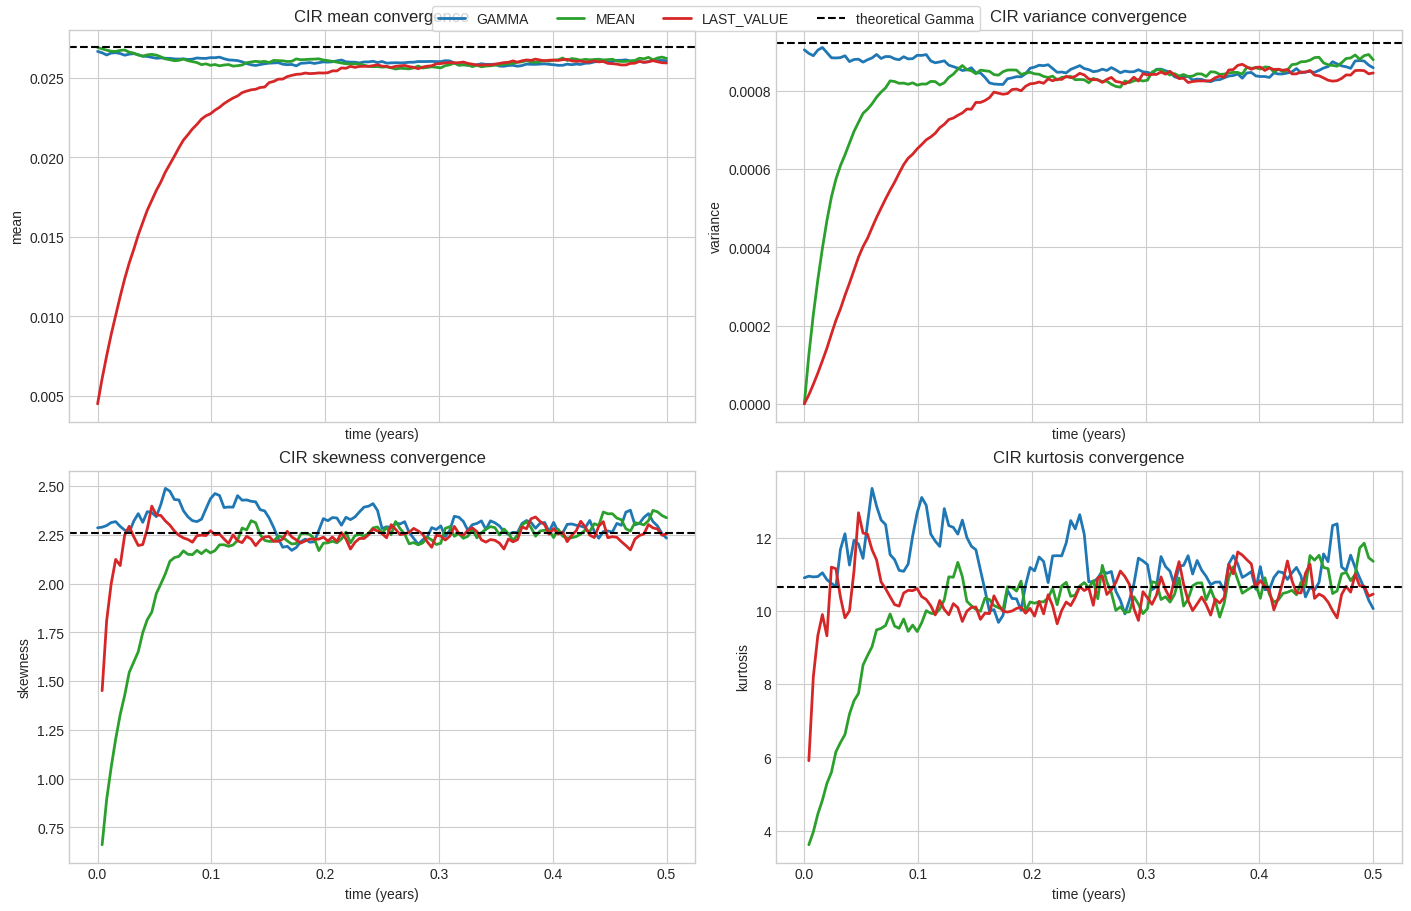

In [ ]:
cir_convergence = cir_moment_paths(cir_half)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, constrained_layout=True)
plot_specs = [
    ("mean", "Mean"),
    ("variance", "Variance"),
    ("skewness", "Skewness"),
    ("kurtosis", "Kurtosis"),
]

for ax, (column, title) in zip(axes.flat, plot_specs):
    for strategy in strategy_order:
        label = strategy_labels[strategy]
        data = cir_convergence[cir_convergence["strategy"] == label]
        ax.plot(data["time"], data[column], color=strategy_colors[strategy], linewidth=2, label=label)
    ax.axhline(cir_theoretical[column], color="black", linestyle="--", linewidth=1.5, label="theoretical Gamma")
    ax.set_title(f"CIR {title.lower()} convergence")
    ax.set_xlabel("time (years)")
    ax.set_ylabel(title.lower())

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=4, frameon=True)
plt.show()


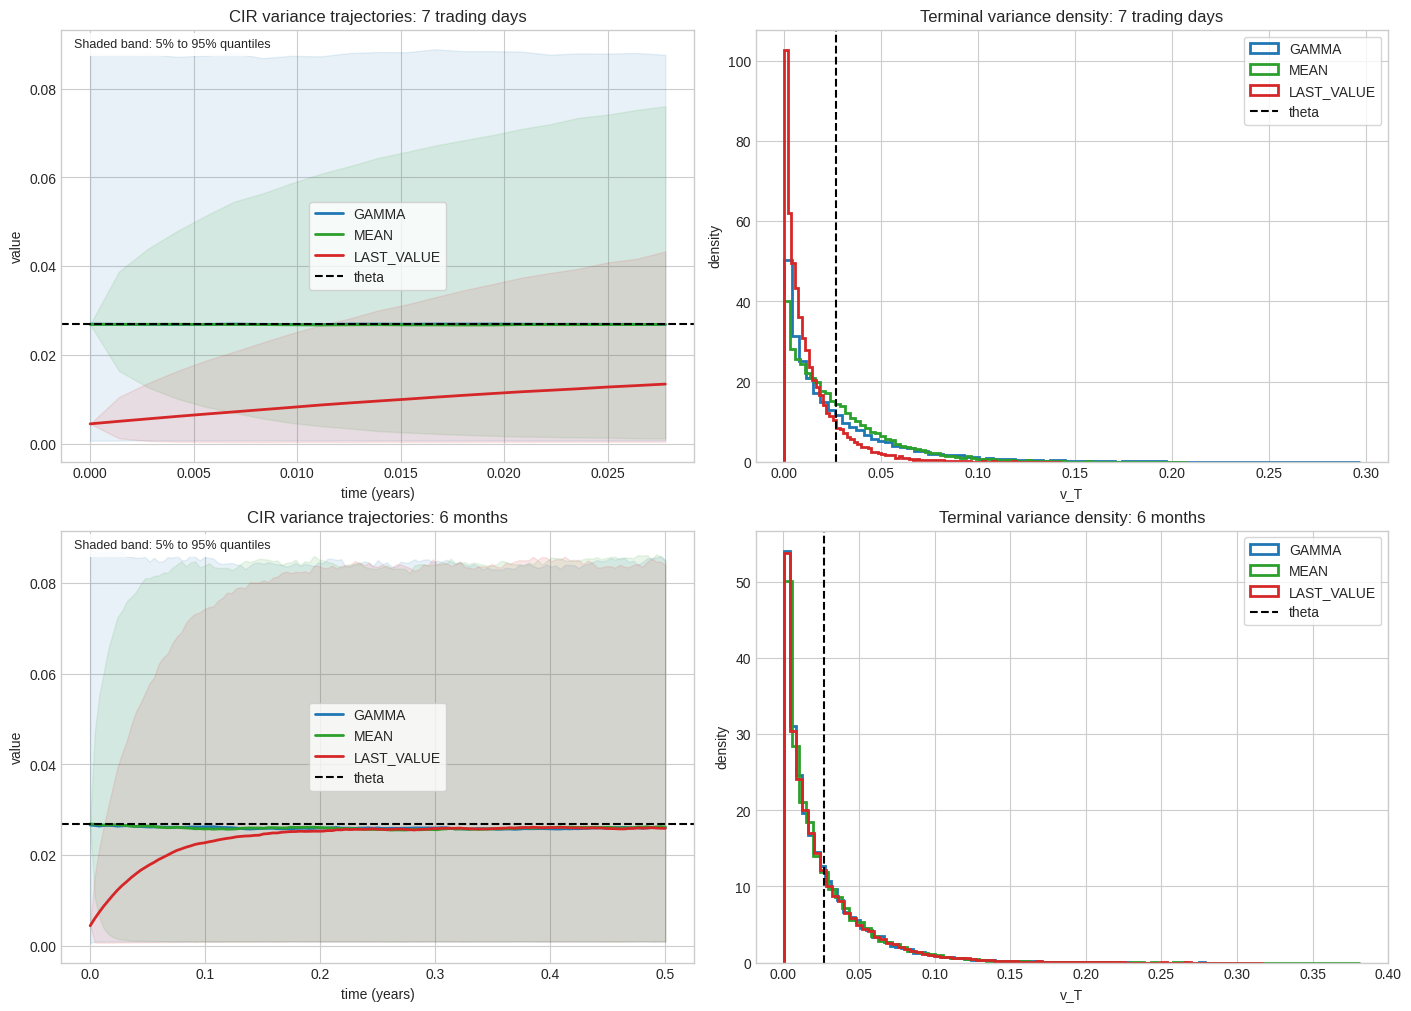

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for row, (label, maturity, bundle) in enumerate(
    [
        ("7 trading days", short_maturity, cir_short),
        ("6 months", half_year, cir_half),
    ]
):
    ax_path, ax_hist = axes[row]

    for strategy in strategy_order:
        times = bundle[strategy]["times"]
        variance = bundle[strategy]["variance"]
        mean_path = variance.mean(axis=0)
        q05, q95 = np.quantile(variance, [0.05, 0.95], axis=0)

        ax_path.plot(times, mean_path, color=strategy_colors[strategy], linewidth=2, label=strategy_labels[strategy])
        ax_path.fill_between(times, q05, q95, color=strategy_colors[strategy], alpha=0.10)

        ax_hist.hist(variance[:, -1], bins=80, density=True, histtype="step", linewidth=2, color=strategy_colors[strategy], label=strategy_labels[strategy])

    ax_path.axhline(theta, color="black", linestyle="--", linewidth=1.5, label="theta")
    ax_path.set_title(f"CIR variance trajectories: {label}")
    ax_path.text(
        0.02,
        0.98,
        "Shaded band: 5% to 95% quantiles",
        transform=ax_path.transAxes,
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    ax_path.set_xlabel("time (years)")
    ax_path.set_ylabel("value")
    ax_path.legend(frameon=True)

    ax_hist.axvline(theta, color="black", linestyle="--", linewidth=1.5, label="theta")
    ax_hist.set_title(f"Terminal variance density: {label}")
    ax_hist.set_xlabel("v_T")
    ax_hist.set_ylabel("density")
    ax_hist.legend(frameon=True)

plt.show()


### CIR takeaways

- `GAMMA` is the only strategy that is stationary from the start. Its mean is already close to `theta`, and more importantly its **whole distribution** is already close to the long-run one at both horizons.
- `MEAN` starts with the correct unconditional mean but with **zero initial dispersion**. Over a short horizon, it understates the left tail near zero and compresses the entire distribution relative to the stationary law.
- `LAST_VALUE` conditions on the current variance regime. Here `0.0045 < theta`, so its short-term distribution starts below the long-run variance level and then mean-reverts upward, exactly as predicted by the formula `E[v_t | v_0] = theta + (v_0 - theta)e^{-kappa t}`.
- By 6 months the three curves are much closer. With `kappa = 19.28`, the memory of the initial condition decays very fast, so the practical difference between the strategies is mostly a **short-maturity** phenomenon.
- The small downward bias in the empirical mean and variance is most likely a discretisation effect of the boosted Milstein CIR scheme, which does not preserve the stationary Gamma law exactly.
- 
This is the key message of the stationary construction: it is not trying to change the long-run CIR behaviour, only the amount of uncertainty injected near time zero.


## 2. Heston simulation under the same three initialisations


We now propagate the same variance choices through the Heston asset dynamics.
The repository uses:

- the boosted Milstein scheme for variance,
- an Euler step on the log-spot,
- a very strong negative correlation `rho = -0.99`.

That last point is important for the interpretation: high variance states should come together with more negative short-term spot moves, so differences in the initial variance law should show up not only in `v_T`, but also in the **shape of the short-maturity spot distribution**.


In [17]:
heston_short = simulate_heston_bundle(
    maturity=short_maturity,
    n_steps=time_steps_for(short_maturity),
    n_paths=n_paths,
    seed=29,
)
heston_half = simulate_heston_bundle(
    maturity=half_year,
    n_steps=time_steps_for(half_year),
    n_paths=n_paths,
    seed=39,
)

heston_summary = pd.concat(
    {
        "7d": summarise_heston_bundle(heston_short, short_maturity),
        "6m": summarise_heston_bundle(heston_half, half_year),
    },
    axis=1,
)

display(heston_summary.round(6))


/home/enzo/code/el_karoui/StationaryHestonModel/notebooks/../stationary_heston_model/diffusions/cir.py:43: UserWarning: The Feller condition is not satisfied.
  warn("The Feller condition is not satisfied.")


7d                                           \
                            E[S_T] risk-neutral target  Std(S_T)   Q05(S_T)   
strategy                                                                      
GAMMA: stationary draw   99.983343           99.984862  2.693034  94.959106   
MEAN: theta             100.000782           99.984862  2.667709  94.828186   
LAST_VALUE: 0.45%        99.982582           99.984862  1.591196  96.788443   

                                                                             \
                          Q95(S_T) P(S_T < 95) P(S_T > 105) Std(log-return)   
strategy                                                                      
GAMMA: stationary draw  103.508150    0.051233       0.0167        0.027438   
MEAN: theta             103.117381    0.053900       0.0000        0.027163   
LAST_VALUE: 0.45%       101.586341    0.015967       0.0000        0.016159   

                                                               ...  \
                       Skew(log-return) Corr(log-return, v_T)  ...   
strategy                                                       ...   
GAMMA: stationary draw        -1.418809             -0.789377  ...   
MEAN: theta                   -1.357901             -0.973792  ...   
LAST_VALUE: 0.45%             -1.913197             -0.968555  ...   

                                        6m                                    \
                       risk-neutral target   Std(S_T)   Q05(S_T)    Q95(S_T)   
strategy                                                                       
GAMMA: stationary draw           99.727871  10.814588  79.723808  114.364302   
MEAN: theta                      99.727871  10.938003  78.799939  114.280725   
LAST_VALUE: 0.45%                99.727871  10.330101  80.246079  113.475351   

                                                                 \
                       P(S_T < 95) P(S_T > 105) Std(log-return)   
strategy                                                          
GAMMA: stationary draw    0.284900     0.355800        0.115960   
MEAN: theta               0.292700     0.357267        0.117707   
LAST_VALUE: 0.45%         0.279467     0.346267        0.110915   

                                                                         
                       Skew(log-return) Corr(log-return, v_T)    E[v_T]  
strategy                                                                 
GAMMA: stationary draw        -1.302686             -0.437618  0.025568  
MEAN: theta                   -1.308844             -0.441560  0.026047  
LAST_VALUE: 0.45%             -1.369805             -0.449784  0.025755  

[3 rows x 22 columns]

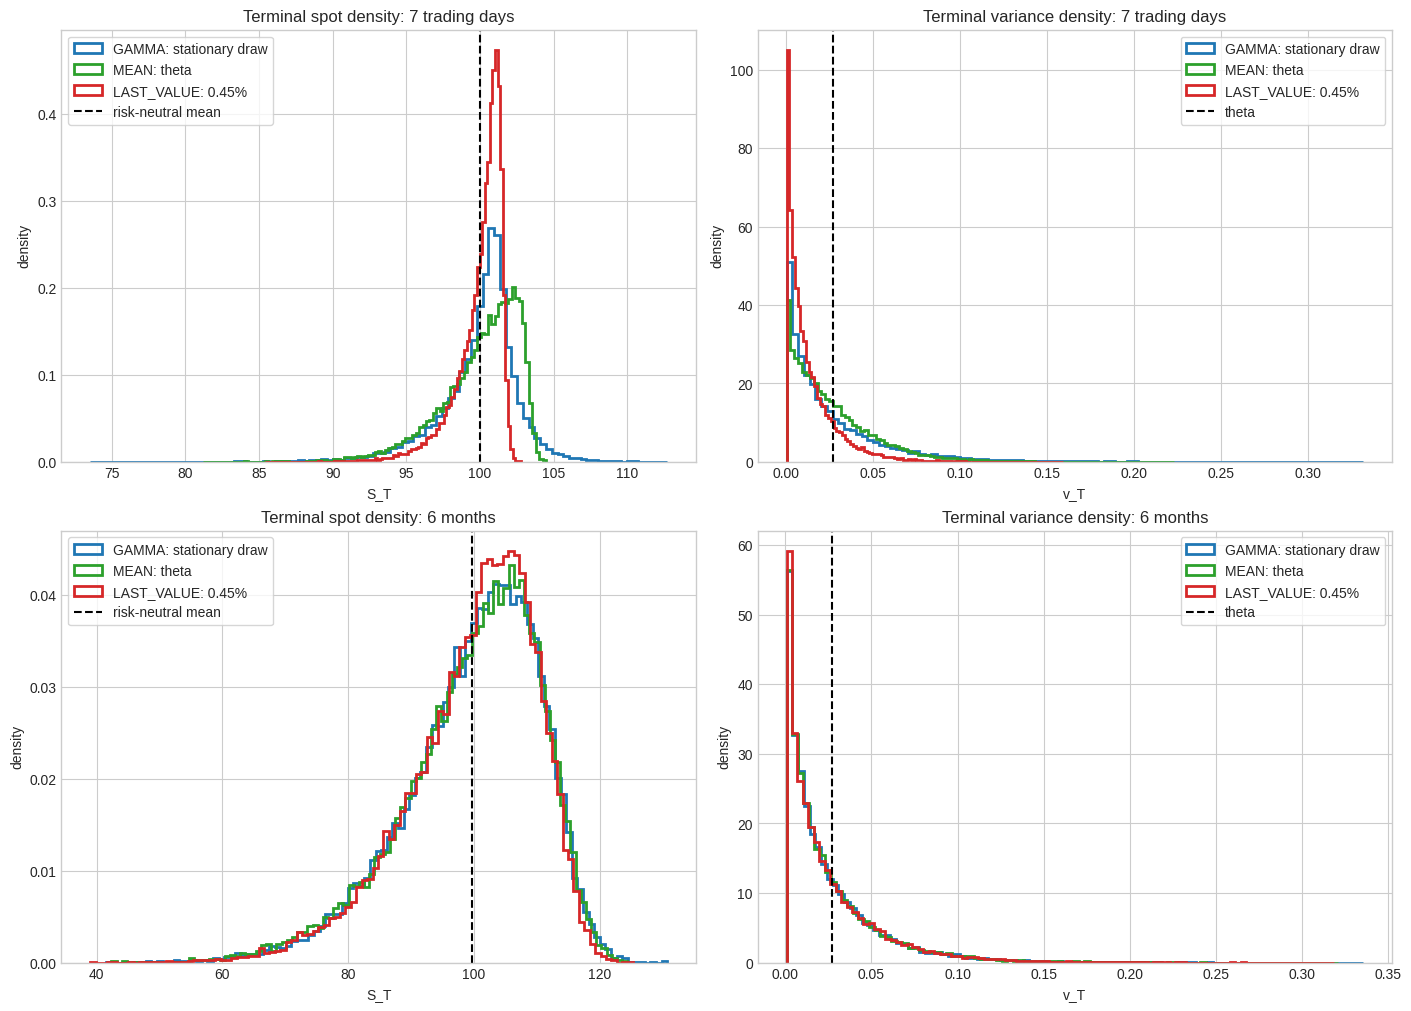

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for row, (label, maturity, bundle) in enumerate(
    [
        ("7 trading days", short_maturity, heston_short),
        ("6 months", half_year, heston_half),
    ]
):
    ax_spot, ax_var = axes[row]
    forward_mean = s0 * np.exp((r - q) * maturity)

    for strategy in strategy_order:
        terminal_spot = bundle[strategy]["spot"][:, -1]
        terminal_var = bundle[strategy]["variance"][:, -1]

        ax_spot.hist(
            terminal_spot,
            bins=100,
            density=True,
            histtype="step",
            linewidth=2,
            color=strategy_colors[strategy],
            label=strategy_labels[strategy],
        )
        ax_var.hist(
            terminal_var,
            bins=100,
            density=True,
            histtype="step",
            linewidth=2,
            color=strategy_colors[strategy],
            label=strategy_labels[strategy],
        )

    ax_spot.axvline(forward_mean, color="black", linestyle="--", linewidth=1.5, label="risk-neutral mean")
    ax_spot.set_title(f"Terminal spot density: {label}")
    ax_spot.set_xlabel("S_T")
    ax_spot.set_ylabel("density")
    ax_spot.legend(frameon=True)

    ax_var.axvline(theta, color="black", linestyle="--", linewidth=1.5, label="theta")
    ax_var.set_title(f"Terminal variance density: {label}")
    ax_var.set_xlabel("v_T")
    ax_var.set_ylabel("density")
    ax_var.legend(frameon=True)

plt.show()


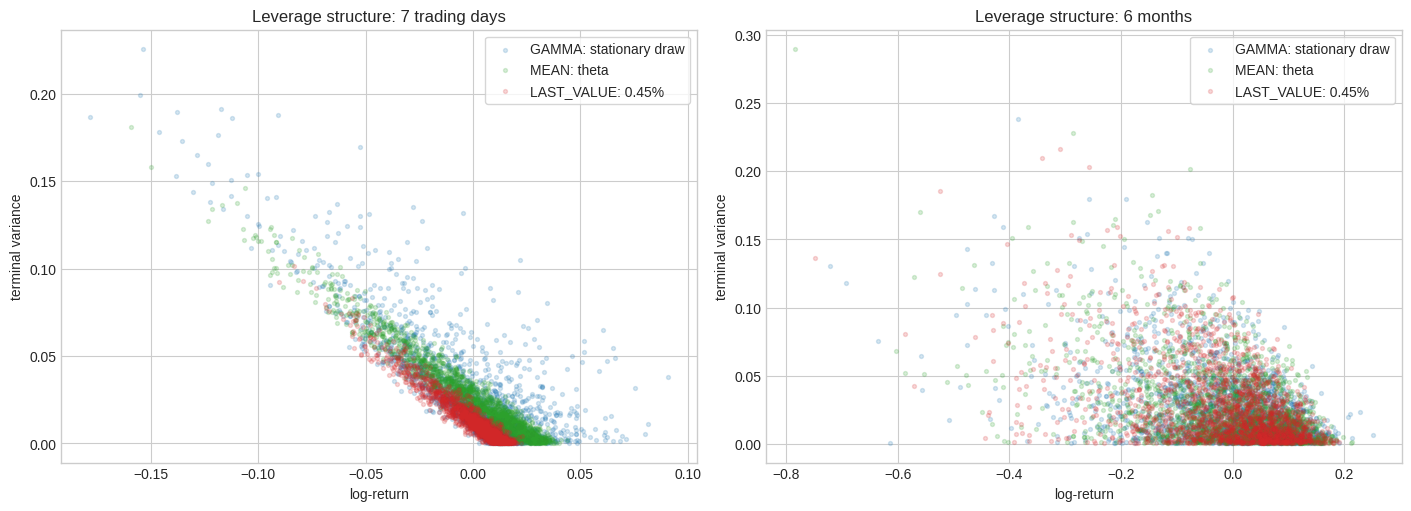

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for axis, (label, bundle, seed) in zip(
    axes,
    [
        ("7 trading days", heston_short, 2026),
        ("6 months", heston_half, 2027),
    ],
):
    for offset, strategy in enumerate(strategy_order):
        terminal_spot = bundle[strategy]["spot"][:, -1]
        terminal_var = bundle[strategy]["variance"][:, -1]
        log_returns = np.log(terminal_spot / s0)

        rng = np.random.default_rng(seed + offset)
        sample_size = min(2_000, terminal_spot.size)
        sample_idx = rng.choice(terminal_spot.size, size=sample_size, replace=False)

        axis.scatter(
            log_returns[sample_idx],
            terminal_var[sample_idx],
            s=8,
            alpha=0.18,
            color=strategy_colors[strategy],
            label=strategy_labels[strategy],
        )

    axis.set_title(f"Leverage structure: {label}")
    axis.set_xlabel("log-return")
    axis.set_ylabel("terminal variance")
    axis.legend(frameon=True)

plt.show()


### Heston takeaways

- The three strategies keep almost the same **risk-neutral mean** for the spot, which is expected: the initialisation mainly changes higher moments, not the drift.
- Over **7 trading days**, the effect is visible. `MEAN` is the least dispersed because it starts from a single variance level equal to `theta`. `LAST_VALUE` is the most dispersed because it starts from `4%`, materially above `theta`, so the variance remains elevated over the whole short horizon.
- `GAMMA` is qualitatively different from `LAST_VALUE`: it does not simply shift the distribution upward. Instead, it creates a **mixture** of low-vol and high-vol states from time zero. With `rho = -0.99`, that mixture widens the spot distribution and reinforces the leverage effect without conditioning on one single variance regime.
- By **6 months**, the three terminal spot distributions are much closer than at 7 days. This mirrors the CIR block: once the variance process has had time to mean-revert, the initialisation choice matters far less.

For the rest of the project, this matters because smile and exotic-option sensitivity are driven mostly by the short end. The stationary initial law is therefore most useful precisely where the standard deterministic start is least flexible.

This concludes **Part 1** of the notebook: the next natural steps are pricing experiments, implied-vol comparisons, and then the exotic products discussed later in the paper.
